In [11]:
!pip install numpy scipy sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import numpy as np
from scipy.spatial import distance
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [3]:
a = np.array([2,3,4])
b = np.array([5,6,7])

In [4]:
euclidean_dist = distance.euclidean(a,b)
euclidean_dist

np.float64(5.196152422706632)

In [5]:
similarity_euclidean = 1/(1+euclidean_dist)
similarity_euclidean

np.float64(0.16139047779640892)

In [6]:
manhattan_distance = distance.cityblock(a,b)
manhattan_distance

np.int64(9)

In [7]:
similarity_manhattan = 1 / (1+manhattan_distance)
similarity_manhattan

np.float64(0.1)

In [8]:
minowaski_dist = distance.minkowski(a,b)
minowaski_dist

np.float64(5.196152422706632)

In [9]:
similarity_minowaski = 1 / (1+minowaski_dist)
similarity_minowaski

np.float64(0.16139047779640892)

In [10]:
tips = pd.read_csv('tips.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'tips.csv'

In [ ]:
corr, p_value = pearsonr(tips['total_bill'],tips['tip'])
corr, p_value

In [ ]:
corr_value, p_value = spearmanr(tips['total_bill'],tips['tip'])
corr_value, p_value

In [ ]:
s1 = "hollow"
s2 = "hellow"

def hamming_distance(s1,s2):
  if len(s1)==len(s2):
    c=0
    for i in range(len(s1)):
      if s1[i] != s2[i]:
        c+=1
    return c
  return ValueError("The Strings must be of same length")

hamming_distance(s1,s2)

In [12]:
from sklearn.feature_extraction import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity




ImportError: cannot import name 'CountVectorizer' from 'sklearn.feature_extraction' (/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/__init__.py)

In [22]:
def lcs_length(X, Y):
    m, n = len(X), len(Y)
    # Create a matrix to store lengths of LCS
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    # Build the matrix
    for i in range(m):
        for j in range(n):
            if X[i] == Y[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1],dp[i+1][j])
    return dp[m][n]

eq1 = "ABCDEF"
eq2 = "AEBDF"
length = lcs_length(eq1, eq2)
print(f"Longest CommonSubsequence length between '{eq1}' and '{eq2}': {length}")

Longest CommonSubsequence length between 'ABCDEF' and 'AEBDF': 4


Objective: Classification: Survived(Yes/No)
Success Criteria: Accuracy >80%
Constraints: Limited features, missing values, imbalanced classes

Dataset Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Data After Preprocessing:
   surviv

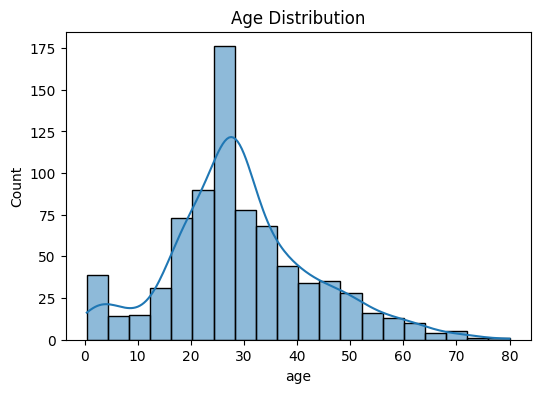

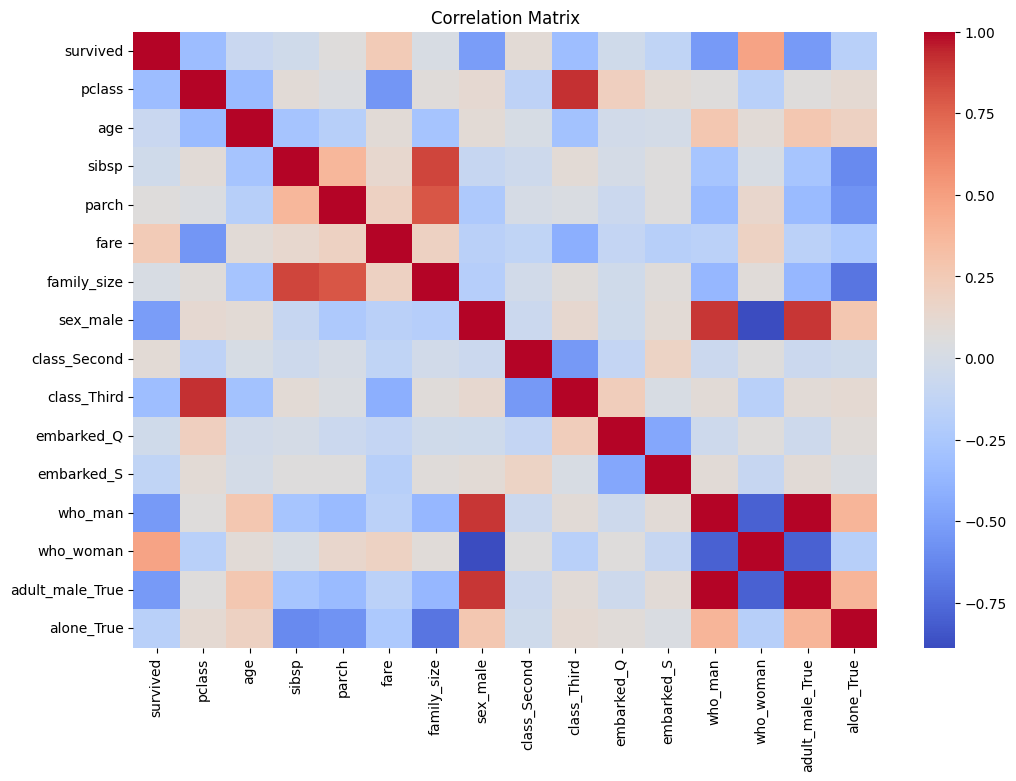


===== Model Evaluation =====
Accuracy : 0.8193548387096774
Precision: 0.7758620689655172
Recall   : 0.75

Confusion Matrix:
[[82 13]
 [15 45]]

First 10 Predictions:
[0 0 0 1 1 1 0 0 0 1]


In [23]:
# 1. Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# ==============================
# 2. Define the Problem
# ==============================
objective = "Classification: Survived(Yes/No)"
success_criteria = "Accuracy >80%"
constraints = "Limited features, missing values, imbalanced classes"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

# ==============================
# 3. Data Collection
# ==============================
df = sns.load_dataset("titanic")

print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# ==============================
# 4. Data Cleaning & Preprocessing
# ==============================
# Handle Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop column with many missing values
df.drop(columns=['deck'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch']

# Convert categorical variables to numerical
df = pd.get_dummies(
    df,
    columns=['sex', 'class', 'embarked', 'who', 'adult_male', 'alone'],
    drop_first=True
)

print("\nData After Preprocessing:")
print(df.head())

# ==============================
# 5. Exploratory Data Analysis
# ==============================
# Histogram of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 6. Data Modeling
# ==============================
# Define Features and Target
X = df.drop(columns=['survived'])
y = df['survived']

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64', 'bool', 'uint8'])

# Convert to integer
X = X.astype(int)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Create Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# ==============================
# 7. Model Evaluation
# ==============================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== Model Evaluation =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("\nConfusion Matrix:")
print(cm)

# ==============================
# 8. Sample Prediction
# ==============================
print("\nFirst 10 Predictions:")
print(y_pred[:10])

In [25]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Using the 'X' variable created in the previous steps as our data
# Standardizing the features ensures they all have a mean of 0 and variance of 1
scaler = StandardScaler()
standardized_data = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
standardized_df = pd.DataFrame(standardized_data, columns=X.columns)

print("Standardized Data (Z-score) - First 5 rows:")
display(standardized_df.head())

Standardized Data (Z-score) - First 5 rows:


,pclass,age,sibsp,parch,fare,family_size,sex_male,class_Second,class_Third,embarked_Q,embarked_S,who_man,who_woman,adult_male_True,alone_True
0,0.883385,-0.549502,0.475876,-0.500754,-0.524225,0.033066,0.777531,-0.518085,0.965748,-0.284416,0.615633,0.865700,-0.690066,0.865700,-1.137057
1,-1.461216,0.612870,0.475876,-0.500754,0.697481,0.033066,-1.286122,-0.518085,-1.035467,-0.284416,-1.624345,-1.155135,1.449138,-1.155135,-1.137057
2,0.883385,-0.258909,-0.534545,-0.500754,-0.524225,-0.624008,-1.286122,-0.518085,0.965748,-0.284416,0.615633,-1.155135,1.449138,-1.155135,0.879463
3,-1.461216,0.394925,0.475876,-0.500754,0.353876,0.033066,-1.286122,-0.518085,-1.035467,-0.284416,0.615633,-1.155135,1.449138,-1.155135,-1.137057
4,0.883385,0.394925,-0.534545,-0.500754,-0.505136,-0.624008,0.777531,-0.518085,0.965748,-0.284416,0.615633,0.865700,-0.690066,0.865700,0.879463
